<h1>Sign language Classification

<h3>All Library Needed

In [1]:
# Import the necessary library
import cv2 # Hodi lee, hadi'a no muda imajen
import numpy as np # Hodi halo serbisu ho array
import matplotlib.pyplot as plt  # Hodi haree imajen (la'ós obrigatoriu, maibé di'ak)
import os           # Hodi halo serbisu ho dalan no pasta sira

# --- CONFIGURATION ---
# 1. DEFINE THE PATH TO ONE TEST IMAGE
# IMPORTANT: Change this placeholder to the actual path of one of your ASL images (e.g., './asl_alphabet_train/A/A_1.jpg')
Resizing_dataset = 'Resizing_dataset/A_resizing' 
# ---------------------

print("Setup complete. Ready to load image.")

Setup complete. Ready to load image.


<h3>Prepare Data Function Definition

In [2]:
# --- KONFIGURASAUN ---
# Fó dalan ba pasta boot ne'ebé iha pasta 'A_resizing', 'B_resizing', no seluk tan.
DATA_DIR = 'Resizing_dataset/' 
IMAGE_SIZE = 400 # Hadi'a imajen hotu-hotu ba dimensaun ida de'it (64x64)
# ---------------------

print("Preparasaun hotu. Pronto atu define funsaun prosesamentu.")

Preparasaun hotu. Pronto atu define funsaun prosesamentu.


<h3>Execution and Array Verification

In [3]:
def load_and_preprocess_data(data_dir, img_size):
    images = [] # Lista hodi rai array feature (X)
    labels = [] # Lista hodi rai letra sira (y)
 
    # La'o liu husi pasta hotu-hotu iha DATA_DIR (e.g., 'A_resizing', 'B_resizing')
    for folder_name in sorted(os.listdir(data_dir)): 
        
        # Harii dalan ba pasta letra nian no haree se loos duni pasta ida ka lae
        label_dir = os.path.join(data_dir, folder_name)
        if not os.path.isdir(label_dir):
            continue
            
        # Hili de'it label (letra) hosi naran pasta nian (e.g., 'A' hosi 'A_resizing')
        label = folder_name[0] 
        print(f"Prosesa pasta ba label: {label} ({folder_name})")
        
        # La'o liu husi imajen ida-idak iha pasta letra nian
        for img_name in os.listdir(label_dir):
            img_path = os.path.join(label_dir, img_name)
            
            # Asegura katak ita lee de'it file (la'ós pasta seluk)
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            # 1. Lee imajen
            img = cv2.imread(img_path)
            if img is None: continue # Se lee la di'ak, salta
                
            # 2. Muda ba Grayscale (Kor mutin-metan)
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # 3. Hadi'a dimensaun imajen nian ba tamañu ne'ebé ita hakarak
            resized_img = cv2.resize(gray_img, (img_size, img_size))
            
            # 4. 'Rai-ketak' (Flatten) array 2D (64x64) ba array 1D (4096)
            # Ne'e mak array feature (vektór karaterístika) ne'ebé KNN presiza
            flattened_img = resized_img.flatten() 
            print("the flattened image is: ", flattened_img)
            # 5. Normaliza Valór Pixel (Hadi'a hosi 0-255 ba 0.0-1.0)
            normalized_img = flattened_img / 255.0
            
            images.append(normalized_img)
            labels.append(label)

    # Muda lista sira ba Array NumPy
    X = np.array(images)
    y = np.array(labels)
    
    return X, y

<h3>Image to Array Transformation

In [4]:
# Hala'o prosesu load no preprosesamentu ba dadus tomak
print("Hahalok prosesamentu dadus hahú...")
X_features, y_labels = load_and_preprocess_data(DATA_DIR, IMAGE_SIZE)

# --- Vérika Dadus ---
print("\n--- Vérika Dadus ne'ebé Transforma Ona ---")
# Ha'u hatete ba ita, array feature (X) ne'e mak hanesan tabela ida:
# Iha: [Imajén Hotu-hotu, Feature (Pixel) Hotu-hotu]

print(f"Total imajen ne'ebé load ona: {X_features.shape[0]}")
# Feature ida-idak iha array ne'e mak pixel ida hosi imajen 64x64 (4096 features)
print(f"Forma matriz Feature X (Imajen, Feature): {X_features.shape}") 
print(f"Forma vektór Label y (Imajen): {y_labels.shape}") 
print(f"Ezemplu valór 5 dahuluk husi vektór feature dahuluk: {X_features[0][:5]}")
print(f"Ezemplu label dahuluk: {y_labels[0]}")

Hahalok prosesamentu dadus hahú...
Prosesa pasta ba label: A (A_resizing)
the flattened image is:  [200 200 201 ... 162 166 168]
the flattened image is:  [200 202 203 ... 175 179 182]
the flattened image is:  [203 201 202 ... 182 177 175]
the flattened image is:  [205 204 202 ... 169 169 173]
the flattened image is:  [204 203 203 ... 157 158 158]
the flattened image is:  [202 203 203 ... 171 172 175]
the flattened image is:  [202 204 204 ... 171 171 172]
the flattened image is:  [203 204 204 ... 158 156 156]
the flattened image is:  [202 200 198 ... 147 147 147]
the flattened image is:  [204 203 202 ... 161 160 162]
the flattened image is:  [203 204 204 ... 166 163 161]
the flattened image is:  [201 202 202 ... 160 161 162]
the flattened image is:  [200 199 199 ... 157 157 156]
the flattened image is:  [201 202 201 ... 172 176 177]
the flattened image is:  [197 198 199 ... 159 160 159]
the flattened image is:  [198 201 203 ... 171 170 166]
the flattened image is:  [198 197 195 ... 157 

In [5]:
print("--- Array Feature (X_features) Ne'ebé Halo ona Normalizasaun ---")

# 1. Forma Array (Shape)
# Hatudu total imajen no total feature (pixel) ida-idak nian
print(f"Forma X_features (Imajen, Feature): {X_features.shape}")

# 2. Vérika Maximu no Mínimu
# Valór tenke besik 1.0 no 0.0
print(f"Valór Máximu: {X_features.max():.4f}")
print(f"Valór Mínimu: {X_features.min():.4f}")

--- Array Feature (X_features) Ne'ebé Halo ona Normalizasaun ---
Forma X_features (Imajen, Feature): (1039, 160000)
Valór Máximu: 0.9412
Valór Mínimu: 0.0000


In [6]:
# Hatudu Vektór Feature  (Image 1)
random_feature_vector = X_features[0]

print("\n--- Valór 40 random husi Imajén  ---")
# Print out valór 40 dahuluk
print(random_feature_vector[:40])

# Hatudu númeru husi elementu iha vektór ida
print(f"\nTotal Features iha Vektór Ida: {random_feature_vector.shape[0]} (e.g., 64x64 = 4096)")


--- Valór 40 random husi Imajén  ---
[0.78431373 0.78431373 0.78823529 0.78823529 0.78039216 0.76862745
 0.77647059 0.79215686 0.78431373 0.77647059 0.77254902 0.77647059
 0.78039216 0.77647059 0.77647059 0.77647059 0.77647059 0.78431373
 0.78431373 0.78039216 0.78039216 0.78431373 0.78039216 0.76862745
 0.77254902 0.78039216 0.78039216 0.77254902 0.77647059 0.77647059
 0.77647059 0.78039216 0.78039216 0.78431373 0.78039216 0.77254902
 0.77254902 0.78039216 0.78039216 0.77647059]

Total Features iha Vektór Ida: 160000 (e.g., 64x64 = 4096)


<h3>LABELING DATA

In [7]:
from sklearn.preprocessing import LabelEncoder

<h3>Fit no Transform Dadus

In [8]:
# Harii Label Encoder
label_encoder = LabelEncoder()

# Fit no Transform: 
# Fit hodi aprende label úniku hotu-hotu (A-Z) no fó numeru ba sira
# Transform hodi troka array y_labels nian ba array numeru
y_encoded = label_encoder.fit_transform(y_labels)

# --- Vérika Rezultadu ---
print("\n--- Array Label Depois Label Encoding ---")
print(f"Array Label Orisinál (String):    {y_labels[:10]}")
print(f"Array Label Códigu Numeru (y):    {y_encoded[:10]}")
print(f"Total klase úniku (letra): {len(label_encoder.classes_)}")

# Salva mapamentu: Ne'e importante tebes hodi troka numeru hikas ba letra
print("\nMapamentu Numeru ba Label:")
for i, label in enumerate(label_encoder.classes_):
    print(f"Códigu {i}: {label}")

# Altera ita-nia array label nian hodi uza array numeru
y_labels = y_encoded


--- Array Label Depois Label Encoding ---
Array Label Orisinál (String):    ['A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A']
Array Label Códigu Numeru (y):    [0 0 0 0 0 0 0 0 0 0]
Total klase úniku (letra): 26

Mapamentu Numeru ba Label:
Códigu 0: A
Códigu 1: B
Códigu 2: C
Códigu 3: D
Códigu 4: E
Códigu 5: F
Códigu 6: G
Códigu 7: H
Códigu 8: I
Códigu 9: J
Códigu 10: K
Códigu 11: L
Códigu 12: M
Códigu 13: N
Códigu 14: O
Códigu 15: P
Códigu 16: Q
Códigu 17: R
Códigu 18: S
Códigu 19: T
Códigu 20: U
Códigu 21: V
Códigu 22: W
Códigu 23: X
Códigu 24: Y
Códigu 25: Z


<h3>SPLIT DATA BA TESTING NO TRAIN NIAN</h3>

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Biblioteka sira importa ona.")

Biblioteka sira importa ona.


<h3>1: Fahe Dadus (Prepara hodi Testa) 🪓

In [10]:
# Fahe dadu: 80% ba Treinu no 20% ba Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_features, 
    y_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_labels # Asegura katak letra hotu-hotu iha porsaun ne'ebé hanesan iha set rua ne'e
)

print(f"\n--- Dadu Fahe Ona ---")
print(f"Tamañu ba set Treinu: {X_train.shape[0]} imajen")
print(f"Tamañu ba set Teste: {X_test.shape[0]} imajen")


--- Dadu Fahe Ona ---
Tamañu ba set Treinu: 831 imajen
Tamañu ba set Teste: 208 imajen


<h3>2: Treinu Modelu K-Nearest Neighbors (KNN) 🧑‍💻

In [11]:
# Hili valór K (vizíñu besik liu), hanesan K=5.
K_VALUE = 3

# Harii modelu KNN
knn_model = KNeighborsClassifier(n_neighbors=K_VALUE)

# Treinu (Fit) modelu hodi uza dadu treinu nian
print(f"\nTreinu modelu KNN ho K={K_VALUE} hahú...")
knn_model.fit(X_train, y_train)
print("Treinu hotu ona!")


Treinu modelu KNN ho K=3 hahú...
Treinu hotu ona!


<h3>3: Prediz no Avalia Rezultadu 📊

<h3>A. Predisaun (Prediction)

In [12]:
# Prediz label ba set teste nian
y_pred = knn_model.predict(X_test)

print("\n--- Ezemplu Predisaun Sira ---")
# Hatudu label 10 loos no predizaun modelu nian
print(f"Loos (y_test):      {y_test[:10]}")
print(f"Prediz (y_pred):   {y_pred[:10]}")


--- Ezemplu Predisaun Sira ---
Loos (y_test):      [ 4 20 10 25 18 17 14  8 23 19]
Prediz (y_pred):   [ 4 20 10 25 18 17 10  8 23 19]


<h3>B. Métrika Avaliasaun (Evaluation Metrics)

In [13]:
# 1. Akurasaun Jerál (Overall Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModelu nia Akurasaun iha Dadus Teste: {accuracy * 100:.2f}%")

# 2. Relatóriu Klasifikasaun Detalladu (Detailed Classification Report)
# Ne'e hatudu Precision, Recall, no F1-score ba letra ida-idak.
print("\n--- Relatóriu Klasifikasaun Detalladu ---")
print(classification_report(y_test, y_pred))

# 3. Matriz Konfuzaun (Confusion Matrix)
# Tabela ne'e hatudu ne'ebé mak modelu halo sala (e.g., konfuza 'C' ho 'O').
conf_matrix = confusion_matrix(y_test, y_pred, labels=np.unique(y_labels))

print("\n--- Forma Matriz Konfuzaun Nian ---")
# Hatudu de'it forma tanba matriz ne'e boot tebes.
print(f"Forma Matriz: {conf_matrix.shape} (e.g., 26x26 ba A-Z)")


Modelu nia Akurasaun iha Dadus Teste: 89.90%

--- Relatóriu Klasifikasaun Detalladu ---
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       0.80      1.00      0.89         8
           5       1.00      1.00      1.00         8
           6       1.00      0.88      0.93         8
           7       0.89      1.00      0.94         8
           8       1.00      1.00      1.00         8
           9       0.75      0.75      0.75         8
          10       0.78      0.88      0.82         8
          11       0.86      0.75      0.80         8
          12       0.75      0.75      0.75         8
          13       0.73      1.00      0.84         8
          14       0.86      0.75      0.80         8
          15       1.00      0.88      0.93   

<h3>Importa Biblioteka no Kria Matriz Konfuzaun

In [14]:
import seaborn as sns
# Assume y_test no y_pred prontu ona hosi prediksaun
# y_test: Label loos husi dadu teste nian
# y_pred: Label ne'ebé modelu prediz

# Asegura katak label encoder ne'e iha nafatin hodi hetan naran klase nian
# (hanesan label_encoder ne'ebé ita harii uluk)
# Se label_encoder ne'e la iha ona, bele harii fali ba iha ne'e:
# label_encoder = LabelEncoder()
# label_encoder.fit(y_labels_original_string_format) # Hodi hanorin klase hotu-hotu

# --- Kria Matriz Konfuzaun ---
# label_encoder.classes_ mak fó alfabetu A-Z iha orden ne'ebé loos
labels_alfabetu = np.unique(y_test) # Ka uza label_encoder.classes_ se label hotu-hotu iha ona
conf_matrix = confusion_matrix(y_test, y_pred, labels=labels_alfabetu)

print("Matriz Konfuzaun kalkula ona.")

Matriz Konfuzaun kalkula ona.


<h3>Desenha (Plot) Diagrama Matriz Konfuzaun Nian

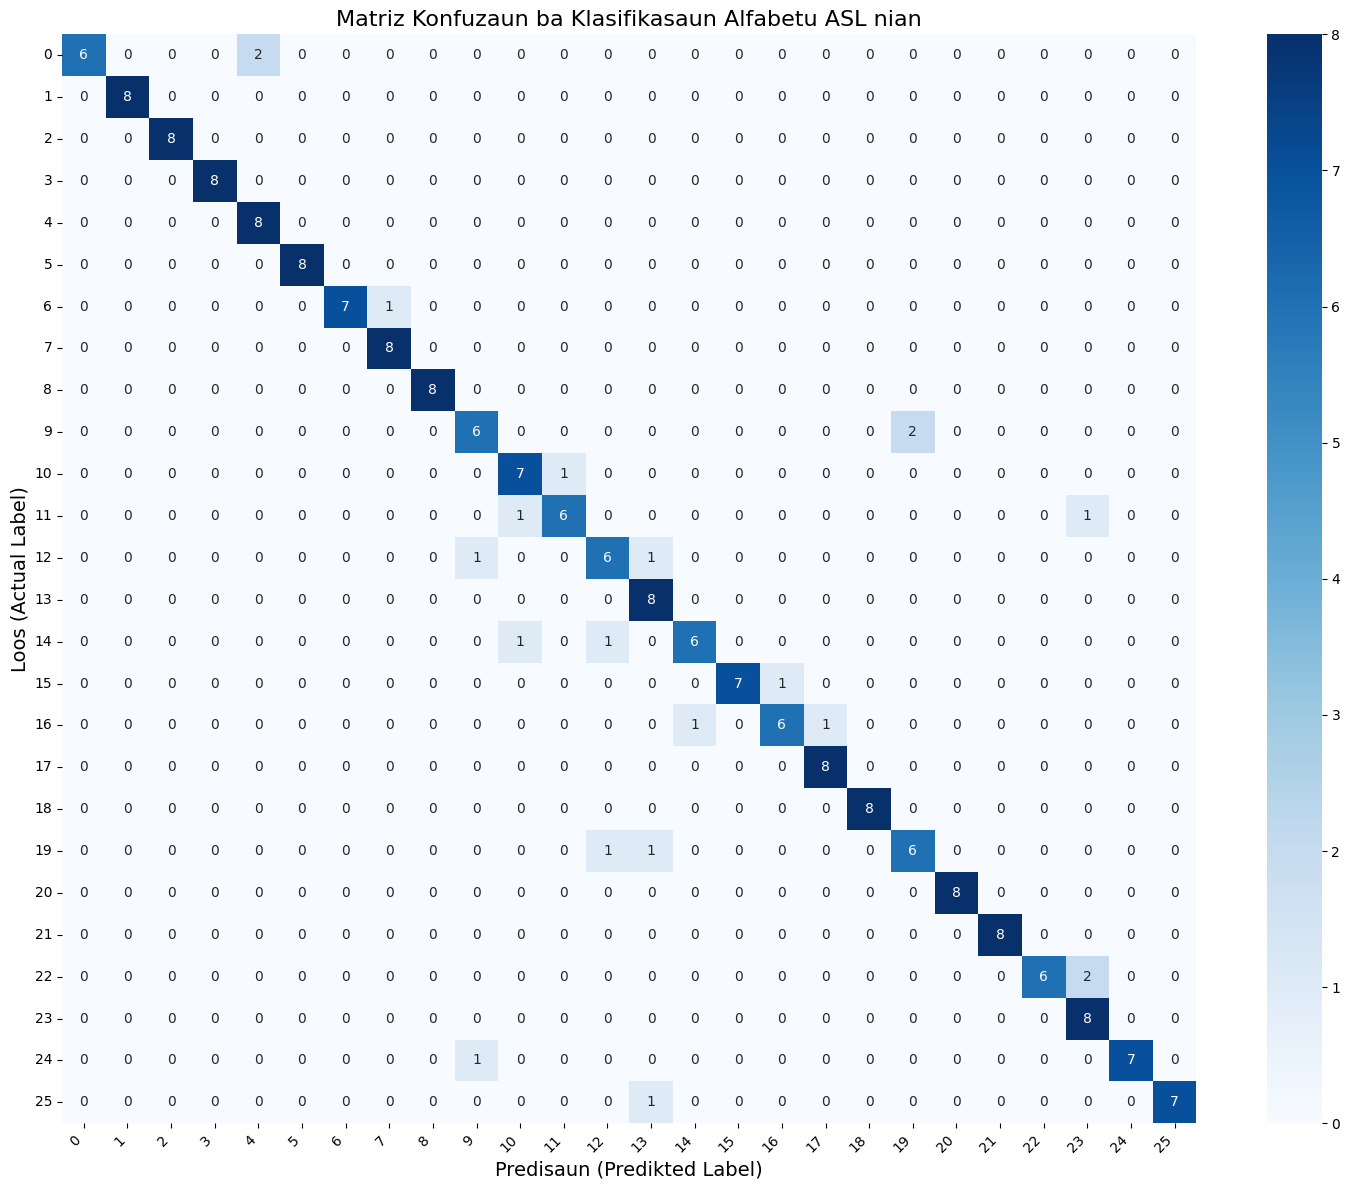

In [15]:
# --- Desenha Diagrama Matriz Konfuzaun ---
plt.figure(figsize=(15, 12)) # Hadi'a tamañu hodi bele haree didi'ak

sns.heatmap(
    conf_matrix,
    annot=True,        # Hatudu valór numeru iha kapa ida-idak
    fmt='d',           # Formatu numeru ba integer
    cmap='Blues',      # Hili kór ba mapa (Blue, YlGnBu, BuPu, etc.)
    xticklabels=labels_alfabetu, # Label ba Eixo X (Prediz)
    yticklabels=labels_alfabetu  # Label ba Eixo Y (Loos)
)

plt.xlabel('Predisaun (Predikted Label)', fontsize=14) # Label Eixo X
plt.ylabel('Loos (Actual Label)', fontsize=14)     # Label Eixo Y
plt.title('Matriz Konfuzaun ba Klasifikasaun Alfabetu ASL nian', fontsize=16) # Títulu
plt.xticks(rotation=45, ha='right') # Halo rotasaun ba label sira iha Eixo X hodi bele lee
plt.yticks(rotation=0)            # Halo rotasaun ba label sira iha Eixo Y
plt.tight_layout()                # Hadi'a layout hodi evita overloap
plt.show()                        # Hatudu diagrama